# Dataset 1: NSL-KDD Exploration

**Goal:** As a machine learning student, your first task is to understand the data you are working with. 
Before we can train an AI to detect cyber attacks, we need to load the raw data, see what it looks like, and understand the balance between normal traffic and malicious attacks.

### Step 0: Import Required Libraries
We only need two standard libraries for this:
- `pandas` for reading and manipulating the data.
- `matplotlib` for drawing graphs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Make our graphs look a bit nicer
plt.style.use('ggplot')

### Step 1: Define the Columns
The raw NSL-KDD dataset (`KDDTrain+.txt`) does not have a header row. If we load it directly, Pandas won't know the names of the features. 
We must manually provide the 43 official column names below.

In [2]:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", 
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", 
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", 
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", 
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", 
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", 
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", 
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

### Step 2: Load the Dataset
Now we use `pd.read_csv()` to load the text file from our `data/raw/` folder, and apply the columns we just defined.

In [3]:
# Define the exact path to the raw dataset
file_path = "../data/raw/nsl-kdd/KDDTrain+.txt"

# Load the data into a Pandas DataFrame (df)
df = pd.read_csv(file_path, names=columns)

# Print out the total number of rows (network connections) we loaded
print(f"Success! Loaded {len(df)} rows.")

Success! Loaded 125973 rows.


### Step 3: Inspect the Data
Let's look at the first 5 rows using `df.head()`. This helps us verify that the data loaded correctly and gives us a feel for the features.

In [4]:
# Display the first 5 rows
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### Step 4: Analyze Attack vs Normal Traffic (Class Distribution)
The `label` column tells us whether a network connection was `normal` or a specific type of attack (like `neptune`, `satan`, etc.).
Let's count how many times each label appears to see what our AI will be learning from.

In [5]:
# Count the occurrences of each unique label
label_counts = df['label'].value_counts()

# Let's print the top 10 most common labels
print("Top 10 Labels in the Dataset:")
print(label_counts.head(10))

Top 10 Labels in the Dataset:
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


### Step 5: Visualize the Distribution
Numbers are great, but charts are better. Let's plot the top 5 labels as a bar chart so we can visually understand the class imbalance. 
*(Notice how `normal` and `neptune` dominate the dataset!)*

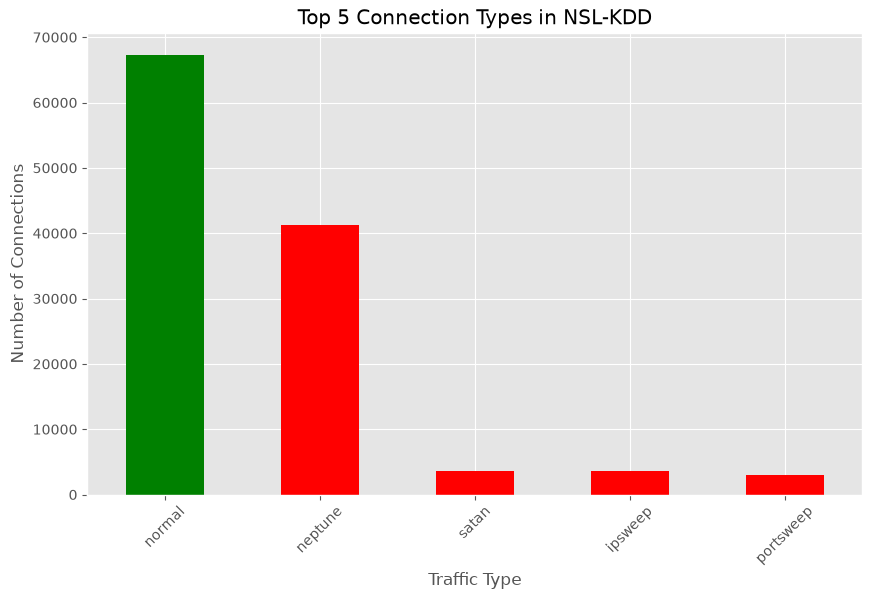

In [6]:
# Take only the top 5 labels for a cleaner graph
top_5_labels = label_counts.head(5)

# Create a bar chart. We will color 'normal' green, and all attacks red.
colors = ['green' if label == 'normal' else 'red' for label in top_5_labels.index]

plt.figure(figsize=(10, 6))
top_5_labels.plot(kind='bar', color=colors)

# Add titles and labels to make the chart professional
plt.title("Top 5 Connection Types in NSL-KDD")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Connections")
plt.xticks(rotation=45) # Tilt the text so it's easier to read

# Show the chart
plt.show()

---
### Step 6: Load the Test Dataset
In Machine Learning, we train the model on a **Training Set** and evaluate it on a completely unseen **Test Set**.
Let's load the `KDDTest+.txt` file and see if its attack distribution looks different from the training data.

In [7]:
# Load the test dataset using the exact same columns
test_file_path = "../data/raw/nsl-kdd/KDDTest+.txt"
df_test = pd.read_csv(test_file_path, names=columns)

print(f"Loaded {len(df_test)} rows for testing.")

# Count the labels in the test set
test_label_counts = df_test['label'].value_counts()
print("\nTop 5 Labels in Test Set:")
print(test_label_counts.head(5))

Loaded 22544 rows for testing.

Top 5 Labels in Test Set:
label
normal          9711
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
Name: count, dtype: int64


### Step 7: The Train/Test Mismatch (Crucial Concept!)
Notice something strange? In the Training set, `neptune` was the most common attack. But in the Test set, `smurf` and `mscan` suddenly appear out of nowhere! 
This is what makes NSL-KDD a difficult dataset: **The AI is forced to detect new cyber attacks in the test set that it never saw during training.**

### Step 7b: Mathematical Proof (Jensen-Shannon Divergence)
We can see with our eyes that the test set has different attacks than the training set. But for a research paper, we need to prove it mathematically.

We use **Jensen-Shannon Divergence**. 
- A score of **0.0** means the datasets are exactly the same.
- A score of **1.0** means they share absolutely nothing in common.
- Anything above **0.3** means the AI will struggle.

In [8]:
from scipy.spatial.distance import jensenshannon

# 1. Convert our label counts into percentages (probabilities)
train_probs = df['label'].value_counts(normalize=True)
test_probs = df_test['label'].value_counts(normalize=True)

# 2. Put them in a side-by-side table. If an attack is missing in one dataset, fill it with 0%
comparison = pd.DataFrame({'Train': train_probs, 'Test': test_probs}).fillna(0)

# 3. Calculate the Jensen-Shannon Divergence
js_score = jensenshannon(comparison['Train'], comparison['Test'])

print(f"Jensen-Shannon Divergence Score: {js_score:.4f}")
if js_score > 0.3:
    print("\nWARNING: The test set is significantly different from the training set!")

Jensen-Shannon Divergence Score: 0.3353



---
### Step 8: Feature Correlation (Finding redundant data)
This dataset has 41 different features (duration, protocol type, bytes sent, etc.). 
Sometimes, two features give the exact same information. For example, if `feature_A` always equals `feature_B`, we can delete one of them to make the AI faster. 
We use a **Correlation Heatmap** to find these redundant features.

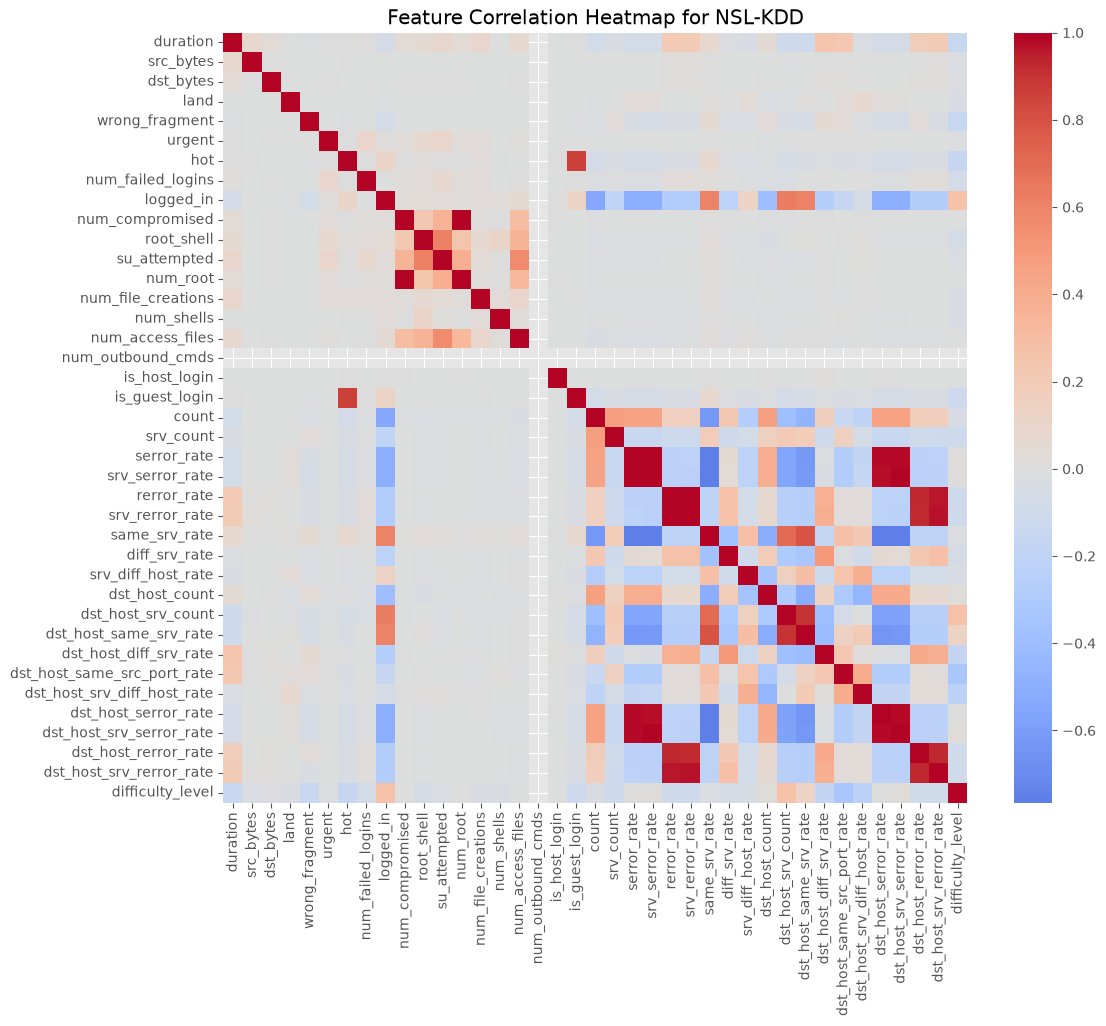

In [9]:
import seaborn as sns

# 1. Select only the numeric columns (we can't find correlations between words like 'tcp' and 'udp')
numeric_cols = df.select_dtypes(include=['number'])

# 2. Calculate the Pearson correlation matrix (how much features move together)
corr_matrix = numeric_cols.corr()

# 3. Draw the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap for NSL-KDD")
plt.show()

---
### Step 9: Feature Importance (Mutual Information)
Not all features are equally useful. Some features (like the length of the connection) might be a huge giveaway that an attack is happening, while other features might be completely useless noise.

We use **Mutual Information (MI)** to calculate how much a feature tells us about the `label`. The higher the score, the more important the feature is for the AI!

Calculating how important each feature is... (this takes a few seconds)


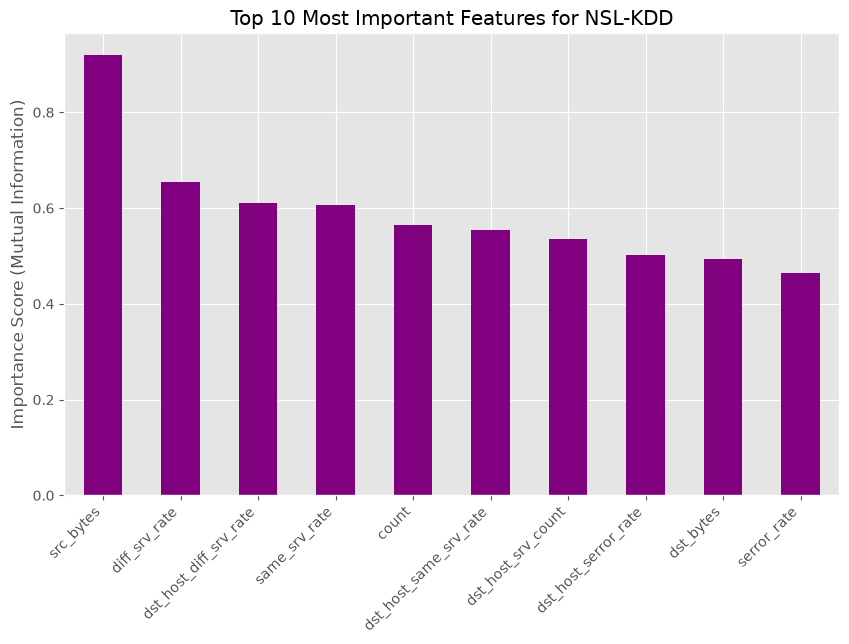

In [10]:
from sklearn.feature_selection import mutual_info_classif

# 1. Take a random sample of 10,000 rows (so your computer doesn't freeze doing the math!)
df_sample = df.sample(10000, random_state=42)

# 2. X = the input features (we only use numerical columns for this test)
X = df_sample.select_dtypes(include=['number'])
# 3. y = the answer we are trying to predict (the attack type)
y = df_sample['label']

# 4. Calculate the Mutual Information score for every single feature
print("Calculating how important each feature is... (this takes a few seconds)")
mi_scores = mutual_info_classif(X, y, random_state=42)

# 5. Match the scores to the column names and sort them from highest to lowest
mi_table = pd.Series(mi_scores, index=X.columns)
mi_table = mi_table.sort_values(ascending=False)

# 6. Plot the Top 10 most important features
plt.figure(figsize=(10, 6))
mi_table.head(10).plot(kind='bar', color='purple')
plt.title("Top 10 Most Important Features for NSL-KDD")
plt.ylabel("Importance Score (Mutual Information)")
plt.xticks(rotation=45, ha='right')
plt.show()

---
### Step 10: EDA Findings & Conclusion (Subphase 10.4)
As a researcher, doing the math is only half the battle. You must write down your conclusions so you know what to do in the Data Cleaning phase! 

Based on our exploration above, here is the official **Action Plan** for NSL-KDD:

1. **Class Imbalance:** The dataset is heavily skewed towards `normal` and `neptune` traffic. 
   * **Action:** We must use a technique like SMOTE (Synthetic Minority Over-sampling) later, or our AI will just blindly guess 'normal' every time and fail to catch rare attacks.
2. **Train/Test Mismatch:** Our Jensen-Shannon divergence proved the test set contains brand new attacks (`mscan`, `smurf`).
   * **Action:** We cannot expect 99% accuracy on this dataset. Our model must focus on generalizing to *patterns* of attacks, rather than memorizing the training data.
3. **Feature Redundancy:** The correlation heatmap showed deep red/blue patches.
   * **Action:** During the cleaning phase, we will write code to automatically delete one of any two features that are >95% correlated to speed up AI training.
4. **Feature Importance:** `src_bytes` and `dst_bytes` are the most powerful indicators of an attack.
   * **Action:** We must ensure these specific features are properly scaled (normalized) so the AI pays close attention to them.